# Kurosiwo Standard (NoFloods)

In [2]:
import matplotlib.font_manager as font_manager
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgb
import numpy as np
import pandas as pd
import torch

fname = '/Library/Fonts/IBM_Plex_Sans/static/IBMPlexSans-Regular.ttf'  # download IBM Plex Sans
font_manager.fontManager.addfont(fname)
prop = font_manager.FontProperties(fname=fname)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()

plt.rcParams.update({
    'font.size': 28,
    'axes.titlesize': 28,
    'axes.labelsize': 28,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'legend.fontsize': 28,
    'figure.titlesize': 28
})

ROOT_DIR = '/Users/BLU/Library/CloudStorage/Box-Box/ACT/00_General/Collaboration/Master_Thesis/Nazar_Risk_Maps/final_notebooks'

In [1]:
# Terraflow
data_tf_base_tds = {
    "tf_base_tds_mIoU": np.array([0.7678, 0.7719, 0.7650, 0.7710, 0.7725]),
    "tf_base_tds_NW":   np.array([0.9880, 0.9884, 0.9880, 0.9884, 0.9888]),
    "tf_base_tds_PW":   np.array([0.7842, 0.7824, 0.7726, 0.7806, 0.7754]),
    "tf_base_tds_F":    np.array([0.8109, 0.8208, 0.8161, 0.8207, 0.8280]),
}

data_tf_base_rs = {
    "tf_base_rs_mIoU": np.array([0.7418, 0.7566, 0.7545, 0.7598, 0.7437]),
    "tf_base_rs_NW":   np.array([0.9862, 0.9870, 0.9880, 0.9873, 0.9870]),
    "tf_base_rs_PW":   np.array([0.7447, 0.7733, 0.7658, 0.7743, 0.7432]),
    "tf_base_rs_F":    np.array([0.7948, 0.7989, 0.8008, 0.8043, 0.7990]),
}

# Terramind
data_tm_base = {
    "tm_base_mIoU": np.array([0.7384, 0.7346, 0.7240, 0.7450, 0.7475]),
    "tm_base_NW":   np.array([0.9863, 0.9862, 0.9853, 0.9864, 0.9868]),
    "tm_base_PW":   np.array([0.7586, 0.7491, 0.7421, 0.7731, 0.7619]),
    "tm_base_F":    np.array([0.7740, 0.7747, 0.7586, 0.7743, 0.7902]),
}

# Temporal model but using Terramind weights
data_tf_tmweights = {
    "tf_tmweights_mIoU": np.array([0.7447, 0.7608, 0.7370, 0.7445, 0.7291]),
    "tf_tmweights_NW":   np.array([0.9863, 0.9867, 0.9860, 0.9861, 0.9836]),
    "tf_tmweights_PW":   np.array([0.7580, 0.7498, 0.7336, 0.7602, 0.7481]),
    "tf_tmweights_F":    np.array([0.7740, 0.7957, 0.7946, 0.7862, 0.7669]),
}

# Temporal model using random weights
data_tf_randweights = {
    "tf_randweights_mIoU": np.array([0.7370, 0.7248, 0.7274, 0.7347, 0.7294]),
    "tf_randweights_NW":   np.array([0.9862, 0.9850, 0.9855, 0.9861, 0.9855]),
    "tf_randweights_PW":   np.array([0.7574, 0.7452, 0.7509, 0.7460, 0.7476]),
    "tf_randweights_F":    np.array([0.7719, 0.7578, 0.7574, 0.7781, 0.7653]),
}

In [2]:
metrics = {
    "mIoU": "IoU",
    "NW": "F1-NW",
    "PW": "F1-PW",
    "F": "F1-F",
}

all_data = {
    "tf_base_tds": data_tf_base_tds,
    "tf_base_rs": data_tf_base_rs,
    "tm_base": data_tm_base,
    "tf_tmweights": data_tf_tmweights,
    "tf_randweights": data_tf_randweights,
}

rows = {}

for name, data in all_data.items():
    rows[name] = {}

    for key, values in data.items():
        parts = key.split("_")
        metric = parts[-1]

        if metric not in metrics:
            continue

        mean = np.mean(values)
        std = np.std(values, ddof=1)  # sample std

        rows[name][metrics[metric]] = f"{mean*100:.2f} ± {std*100:.2f}"

df = pd.DataFrame.from_dict(rows, orient="index")
df = df[["F1-NW", "F1-PW", "F1-F", "IoU"]]
df = df.loc[
    ["tm_base", "tf_randweights", "tf_tmweights", "tf_base_rs", "tf_base_tds"]
]

df = df.rename(index={
    "tm_base": "TerraMind-V1-Base",
    "tf_randweights": "TerraFlow-Base-RandWeights",
    "tf_tmweights": "TerraFlow-Base-TerraMindWeights",
    "tf_base_rs": "TerraFlow-Base-RS",
    "tf_base_tds": "TerraFlow-Base-TDS",
})

print(df)


                                        F1-NW         F1-PW          F1-F  \
TerraMind-V1-Base                98.62 ± 0.06  75.70 ± 1.19  77.44 ± 1.12   
TerraFlow-Base-RandWeights       98.57 ± 0.05  74.94 ± 0.50  76.61 ± 0.90   
TerraFlow-Base-TerraMindWeights  98.57 ± 0.12  74.99 ± 1.05  78.35 ± 1.27   
TerraFlow-Base-RS                98.71 ± 0.06  76.03 ± 1.53  79.96 ± 0.34   
TerraFlow-Base-TDS               98.83 ± 0.03  77.90 ± 0.49  81.93 ± 0.63   

                                          IoU  
TerraMind-V1-Base                73.79 ± 0.93  
TerraFlow-Base-RandWeights       73.07 ± 0.51  
TerraFlow-Base-TerraMindWeights  74.32 ± 1.17  
TerraFlow-Base-RS                75.13 ± 0.80  
TerraFlow-Base-TDS               76.96 ± 0.32  


In [3]:
print(df.to_latex())

\begin{tabular}{lllll}
\toprule
 & F1-NW & F1-PW & F1-F & IoU \\
\midrule
TerraMind-V1-Base & 98.62 ± 0.06 & 75.70 ± 1.19 & 77.44 ± 1.12 & 73.79 ± 0.93 \\
TerraFlow-Base-RandWeights & 98.57 ± 0.05 & 74.94 ± 0.50 & 76.61 ± 0.90 & 73.07 ± 0.51 \\
TerraFlow-Base-TerraMindWeights & 98.57 ± 0.12 & 74.99 ± 1.05 & 78.35 ± 1.27 & 74.32 ± 1.17 \\
TerraFlow-Base-RS & 98.71 ± 0.06 & 76.03 ± 1.53 & 79.96 ± 0.34 & 75.13 ± 0.80 \\
TerraFlow-Base-TDS & 98.83 ± 0.03 & 77.90 ± 0.49 & 81.93 ± 0.63 & 76.96 ± 0.32 \\
\bottomrule
\end{tabular}



# Kurosiwo Floods

In [4]:
data_tm_tiny = {
    "mIoU": np.array([0.2321, 0.2341, 0.2331, 0.2303, 0.2319]),
    "Brier": np.array([0.125438, 0.125133, 0.125699, 0.124751, 0.103391]),
}

data_tf_tiny_randw = {
    "mIoU": np.array([0.1891, 0.1888, 0.1897, 0.1887, 0.1889]),
    "Brier": np.array([0.117489, 0.110475, 0.117444, 0.117678, 0.117622]),
}

data_tm_tiny_tmweight = {
    "mIoU": np.array([0.2943, 0.3083, 0.2952, 0.2933, 0.3104]),
    "Brier": np.array([0.110985, 0.109796, 0.109258, 0.11095, 0.111259]),
}

data_tf_tiny_rs = {
    "mIoU": np.array([0.3113, 0.3123, 0.3125, 0.3083, 0.3253]),
    "Brier": np.array([0.114374, 0.114886, 0.110527, 0.107833, 0.118492]),
}

data_tf_tiny_tds = {
    "mIoU": np.array([0.269, 0.2639, 0.2694, 0.2685, 0.2672]),
    "Brier": np.array([0.143831, 0.138967, 0.140516, 0.141034, 0.142815]),
}

data_resnet18 = {
    "mIoU": np.array([0.2346, 0.2363, 0.2378, 0.2297, 0.2394]),
    "Brier": np.array([0.160347, 0.136043, 0.146716, 0.143104, 0.152443]),
}

data_resnet50 = {
    "mIoU": np.array([0.2439, 0.2267, 0.2357, 0.2269, 0.217]),
    "Brier": np.array([0.167594, 0.157846, 0.150631, 0.144242, 0.154022]),
}

data_resnet101 = {
    "mIoU": np.array([0.2478, 0.2178, 0.2191, 0.2383, 0.2078]),
    "Brier": np.array([0.186414, 0.152417, 0.136716, 0.146873, 0.144579]),
}

data_tm_base = {
    "mIoU": np.array([0.2512, 0.258, 0.2616, 0.2391, 0.238]),
    "Brier": np.array([0.166015, 0.167181, 0.151845, 0.16008, 0.171379]),
}

data_tf_base_randweight = {
    "mIoU": np.array([0.1653, 0.1683, 0.163, 0.1646, 0.1639]),
    "Brier": np.array([0.125438, 0.111975, 0.125699, 0.124751, 0.123159]),
}

data_tm_base_tmweight = {
    "mIoU": np.array([0.2897, 0.2954, 0.285, 0.2956, 0.2891]),
    "Brier": np.array([0.101333, 0.104292, 0.103678, 0.10098, 0.101694]),
}


data_tf_base_rs = {
    "mIoU": np.array([0.3723, 0.3906, 0.3827, 0.3907, 0.3659]),
    "Brier": np.array([0.099096, 0.094065, 0.095529, 0.099759, 0.094111]),
}

data_tf_base_tds = {
    "mIoU": np.array([0.3623, 0.3622, 0.3623, 0.3609, 0.3546]),
    "Brier": np.array([0.111369, 0.109586, 0.112065, 0.10955, 0.111405]),
}

data_tf_base_rs_rmse = {
    "mIoU": np.array([0.3823, 0.3219, 0.3645, 0.3593, 0.3373]),
    "Brier": np.array([0.091312, 0.088972, 0.087164, 0.09511, 0.091017]),
}

data_tf_base_tds_rmse = {
    "mIoU": np.array([0.3448, 0.3345, 0.3643, 0.3593, 0.3581]),
    "Brier": np.array([0.094815, 0.095738, 0.095583, 0.09511, 0.094895]),
}

In [5]:
# -------------------------------------------------
# Models (same order as provided)
# -------------------------------------------------
models = [
    "resnet18",
    "resnet50",
    "resnet101",
    "tm_tiny",
    "tf_tiny_randw",
    "tf_tiny_tmweight",
    "tf_tiny_rs",
    "tf_tiny_tds",
    "tm_base",
    "tf_base_randweight",
    "tf_base_tmweight",
    "tf_base_rs",
    "tf_base_tds",
    "tf_base_rs_rmse",
    "tf_base_tds_rmse",
]

all_data = {
    "tm_tiny": data_tm_tiny,
    "tf_tiny_randw": data_tf_tiny_randw,
    "tf_tiny_tmweight": data_tm_tiny_tmweight,
    "tf_tiny_rs": data_tf_tiny_rs,
    "tf_tiny_tds": data_tf_tiny_tds,
    "resnet18": data_resnet18,
    "resnet50": data_resnet50,
    "resnet101": data_resnet101,
    "tm_base": data_tm_base,
    "tf_base_randweight": data_tf_base_randweight,
    "tf_base_tmweight": data_tm_base_tmweight,
    "tf_base_rs": data_tf_base_rs,
    "tf_base_tds": data_tf_base_tds,
    "tf_base_rs_rmse": data_tf_base_rs_rmse,
    "tf_base_tds_rmse": data_tf_base_tds_rmse,
}

# -------------------------------------------------
# Pretty names (paper-ready)
# -------------------------------------------------
pretty_names = {
    "tm_tiny": "TerraMind-Tiny",
    "tf_tiny_randw": "TerraFlow-Tiny-RandWeights",
    "tf_tiny_tmweight": "TerraFlow-Tiny-TerraMindWeights",
    "tf_tiny_rs": "TerraFlow-Tiny-RS",
    "tf_tiny_tds": "TerraFlow-Tiny-TDS",
    "resnet18": "RESNET18",
    "resnet50": "RESNET50",
    "resnet101": "RESNET101",
    "tm_base": "TerraMind-Base",
    "tf_base_randweight": "TerraFlow-Base-RandWeights",
    "tf_base_tmweight": "TerraFlow-Base-TerraMindWeights",
    "tf_base_rs": "TerraFlow-Base-RS",
    "tf_base_tds": "TerraFlow-Base-TDS",
    "tf_base_rs_rmse": "TerraFlow-Base-RS-RMSE",
    "tf_base_tds_rmse": "TerraFlow-Base-TDS-RMSE",
}

# -------------------------------------------------
# Mean / std (over runs)
# -------------------------------------------------
mean_df = pd.DataFrame(
    {
        m: {
            "mIoU ↑": np.mean(all_data[m]["mIoU"]) * 100,
            "Brier ↓": np.mean(all_data[m]["Brier"]) * 100,
        }
        for m in models
    }
).T

std_df = pd.DataFrame(
    {
        m: {
            "mIoU ↑": np.std(all_data[m]["mIoU"]) * 100,
            "Brier ↓": np.std(all_data[m]["Brier"]) * 100,
        }
        for m in models
    }
).T

# -------------------------------------------------
# Combine into "mean ± std"
# -------------------------------------------------
mean_std_df = mean_df.copy()
for m in models:
    for metric in ["mIoU ↑", "Brier ↓"]:
        mean_std_df.loc[m, metric] = (
            f"{mean_df.loc[m, metric]:.1f} ± {std_df.loc[m, metric]:.1f}"
        )

# -------------------------------------------------
# Replace index with pretty names
# -------------------------------------------------
mean_std_df.index = [pretty_names[m] for m in mean_std_df.index]
mean_df.index = mean_std_df.index  # keep alignment for styling

# -------------------------------------------------
# Styling (best & second-best)
# -------------------------------------------------
def highlight_best_and_second(col):
    means = mean_df[col.name]
    order = means.sort_values(ascending=("↓" in col.name))
    best, second = order.iloc[0], order.iloc[1]
    return [
        "font-weight: bold;" if means.loc[i] == best
        else "text-decoration: underline;" if means.loc[i] == second
        else ""
        for i in col.index
    ]

styled = mean_std_df.style.apply(highlight_best_and_second, axis=0)
display(styled)


/var/folders/n0/spwpp7n90qj9zm8hg_hjcd_w0000gn/T/ipykernel_20805/3413690616.py:90: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '23.6 ± 0.3' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mean_std_df.loc[m, metric] = (
/var/folders/n0/spwpp7n90qj9zm8hg_hjcd_w0000gn/T/ipykernel_20805/3413690616.py:90: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '14.8 ± 0.8' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mean_std_df.loc[m, metric] = (


,mIoU ↑,Brier ↓
RESNET18,23.6 ± 0.3,14.8 ± 0.8
RESNET50,23.0 ± 0.9,15.5 ± 0.8
RESNET101,22.6 ± 1.5,15.3 ± 1.7
TerraMind-Tiny,23.2 ± 0.1,12.1 ± 0.9
TerraFlow-Tiny-RandWeights,18.9 ± 0.0,11.6 ± 0.3
TerraFlow-Tiny-TerraMindWeights,30.0 ± 0.7,11.0 ± 0.1
TerraFlow-Tiny-RS,31.4 ± 0.6,11.3 ± 0.4
TerraFlow-Tiny-TDS,26.8 ± 0.2,14.1 ± 0.2
TerraMind-Base,25.0 ± 1.0,16.3 ± 0.7
TerraFlow-Base-RandWeights,16.5 ± 0.2,12.2 ± 0.5


In [6]:
def format_for_latex(mean_df, mean_std_df):
    latex_df = mean_std_df.copy()

    for col in mean_df.columns:
        means = mean_df[col]
        ascending = ("↓" in col)
        order = means.sort_values(ascending=ascending)
        best, second = order.index[0], order.index[1]

        latex_df.loc[best, col] = r"\textbf{" + latex_df.loc[best, col] + "}"
        latex_df.loc[second, col] = r"\underline{" + latex_df.loc[second, col] + "}"

    return latex_df

latex_df = format_for_latex(mean_df, mean_std_df)

latex_table = latex_df.to_latex(
    escape=False,        # allow LaTeX commands
    column_format="lcc", # adjust if you add columns
    caption="Model comparison on mIoU and Brier score",
    label="tab:results",
)

print(latex_table)


\begin{table}
\caption{Model comparison on mIoU and Brier score}
\label{tab:results}
\begin{tabular}{lcc}
\toprule
 & mIoU ↑ & Brier ↓ \\
\midrule
RESNET18 & 23.6 ± 0.3 & 14.8 ± 0.8 \\
RESNET50 & 23.0 ± 0.9 & 15.5 ± 0.8 \\
RESNET101 & 22.6 ± 1.5 & 15.3 ± 1.7 \\
TerraMind-Tiny & 23.2 ± 0.1 & 12.1 ± 0.9 \\
TerraFlow-Tiny-RandWeights & 18.9 ± 0.0 & 11.6 ± 0.3 \\
TerraFlow-Tiny-TerraMindWeights & 30.0 ± 0.7 & 11.0 ± 0.1 \\
TerraFlow-Tiny-RS & 31.4 ± 0.6 & 11.3 ± 0.4 \\
TerraFlow-Tiny-TDS & 26.8 ± 0.2 & 14.1 ± 0.2 \\
TerraMind-Base & 25.0 ± 1.0 & 16.3 ± 0.7 \\
TerraFlow-Base-RandWeights & 16.5 ± 0.2 & 12.2 ± 0.5 \\
TerraFlow-Base-TerraMindWeights & 29.1 ± 0.4 & 10.2 ± 0.1 \\
TerraFlow-Base-RS & \textbf{38.0 ± 1.0} & 9.7 ± 0.2 \\
TerraFlow-Base-TDS & \underline{36.0 ± 0.3} & 11.1 ± 0.1 \\
TerraFlow-Base-RS-RMSE & 35.3 ± 2.1 & \textbf{9.1 ± 0.3} \\
TerraFlow-Base-TDS-RMSE & 35.2 ± 1.1 & \underline{9.5 ± 0.0} \\
\bottomrule
\end{tabular}
\end{table}



# Figure 

In [12]:
################################# BENEDIKTS CODE #####################################
def dem_to_rgb(data, cmap='BrBG_r', buffer=5):
    if isinstance(data, torch.Tensor):
        # to numpy
        data = data.clone().cpu().numpy()
    while len(data.shape) > 2:
        # Remove batch dim etc.
        data = data[0]

    # Add 10m buffer to highlight flat areas
    data_min, data_max = data.min(), data.max()
    data_min -= buffer
    data_max += buffer
    data = (data - data_min) / (data_max - data_min + 1e-6)

    rgb = plt.get_cmap(cmap)(data)[:, :, :3]
    rgb = (rgb * 255).round().clip(0, 255).astype(np.uint8)
    return rgb

def s2_to_rgb(data, smooth_quantiles=True, gamma=0.5):
    if isinstance(data, torch.Tensor):
        # to numpy
        data = data.clone().cpu().numpy()
    if len(data.shape) == 4:
        # Remove batch dim
        data = data[0]

    # Select
    if data.shape[0] > 13:
        # assuming channel last
        rgb = data[:, :, [3, 2, 1]]
    else:
        # assuming channel first
        rgb = data[[3, 2, 1]].transpose((1, 2, 0))

    if smooth_quantiles:
        min_value, q99_value = np.quantile(rgb, q=[0., 0.99])
        min_value = min_value.clip(0, 1000) # Clip scaling
        q99_value = q99_value.clip(2000, 20000)
        scaled = (rgb - min_value) / (q99_value - min_value + 1e-6)
        fixed  = rgb / 2000

        if gamma is not None and q99_value > 3000:
            scaled = np.power(scaled, gamma)

        rgb = 0.7 * scaled + 0.3 * fixed

        # t0, t1 = 1500, 2500
        #
        # w = np.clip((rgb - t0) / (t1 - t0), 0, 1)          # blend weight
        # w = w * w * (3 - 2 * w)                            # smoothstep
        #
        # min_value, q99_value = np.quantile(rgb, [0., 0.99])
        # min_value = min_value.clip(0, 1000)
        # q99_value = q99_value.clip(2000, 20000)
        #
        # scaled = (rgb - min_value) / (q99_value - min_value + 1e-6)
        # fixed  = rgb / 3000
        #
        # rgb = (1 - w) * fixed + w * scaled
    else:
        rgb = rgb / 2000

    rgb = rgb.clip(0, 1)

    # to uint8
    rgb = (rgb * 255).round().astype(np.uint8)

    return rgb

def s1_to_rgb(data):
    if isinstance(data, torch.Tensor):
        # to numpy
        data = data.clone().cpu().numpy()
    if len(data.shape) == 4:
        # Remove batch dim
        data = data[0]

    vv = data[0]
    vh = data[1]
    r = (vv + 30) / 40  # scale -30 to +10
    g = (vh + 40) / 40  # scale -40 to +0
    b = vv / vh.clip(-40, -1) / 1.5  # VV / VH

    rgb = np.dstack([r, g, b])
    rgb = (rgb * 255).round().clip(0, 255).astype(np.uint8)
    return rgb


def s1_to_power(data):
    # Convert dB to power
    data = 10 ** (data / 10)
    return data * 10000

def s1_power_to_rgb(data):
    if isinstance(data, torch.Tensor):
        # to numpy
        data = data.clone().cpu().numpy()
    if len(data.shape) == 4:
        # Remove batch dim
        data = data[0]

    vv = data[0]
    vh = data[1]
    r = vv / 500
    g = vh / 2200
    b = vv / vh / 2

    rgb = np.dstack([r, g, b])
    rgb = (rgb * 255).round().clip(0, 255).astype(np.uint8)
    return rgb

COLORS = {
    "red": {
        "pos": "#9F1853", # plum
        "mid": "#D02670", # magenta
        "neg": "#F4F4F4",
    },


    "blue": {
        "pos": "#003A6D", # dark blue
        "mid": "#0F62FE", # blue
        "neg": "#F4F4F4",
    }
}

from scipy.ndimage import gaussian_filter
def process_pred(pred, thr=0.2, sigma=20):
    w = np.clip((thr - pred) / thr, 0, 1)   # 1 for very low, 0 at >=thr
    low = gaussian_filter(pred * w, sigma=sigma)
    norm = gaussian_filter(w, sigma=sigma) + 1e-6
    low = low / norm
    # blend back
    pred = pred * (1 - w) + low * w
    return pred

In [13]:
inputs = torch.load(f"{ROOT_DIR}/load_samples/kurosiwo/kuro_inputs.pt", map_location="cpu")
tm_outputs = torch.softmax(torch.load(f"{ROOT_DIR}/load_samples/kurosiwo/kuro_outputs_nt.pt", map_location="cpu"), dim=1)[:,2,:,:]
tf_rs_outputs = torch.softmax(torch.load(f"{ROOT_DIR}/load_samples/kurosiwo/kuro_outputs_rs.pt", map_location="cpu"), dim=1)[:,2,:,:]
tf_tds_outputs = torch.softmax(torch.load(f"{ROOT_DIR}/load_samples/kurosiwo/kuro_outputs_tds.pt", map_location="cpu"), dim=1)[:,2,:,:]
# outputs = torch.softmax(torch.load(f"{ROOT_DIR}/load_samples/kurosiwo/kuro_outputs.pt", map_location="cpu"), dim=1)[:,2,:,:]
targets = torch.load(f"{ROOT_DIR}/load_samples/kurosiwo/kuro_targets.pt", map_location="cpu")

# Denormalize inputs
mean = {
    "SEN2L2A": [1390.458, 1503.317, 1718.197, 1853.91, 2199.1, 2779.975, 2987.011, 3083.234, 3132.22, 3162.988, 2424.884, 1857.648],
    "SEN1GRD": [-12.599, -20.293],
    "DEM": [670.665],
}

std = {
    "SEN2L2A": [2106.761, 2141.107, 2038.973, 2134.138, 2085.321, 1889.926, 1820.257, 1871.918, 1753.829, 1797.379, 1434.261, 1334.311],
    "SEN1GRD": [5.195, 5.890],
    "DEM": [951.272],
}

for k, v in list(inputs.items()):
    inputs[k] = v * torch.tensor(std[k])[None, :, None, None, None] + torch.tensor(mean[k])[None, :, None, None, None]

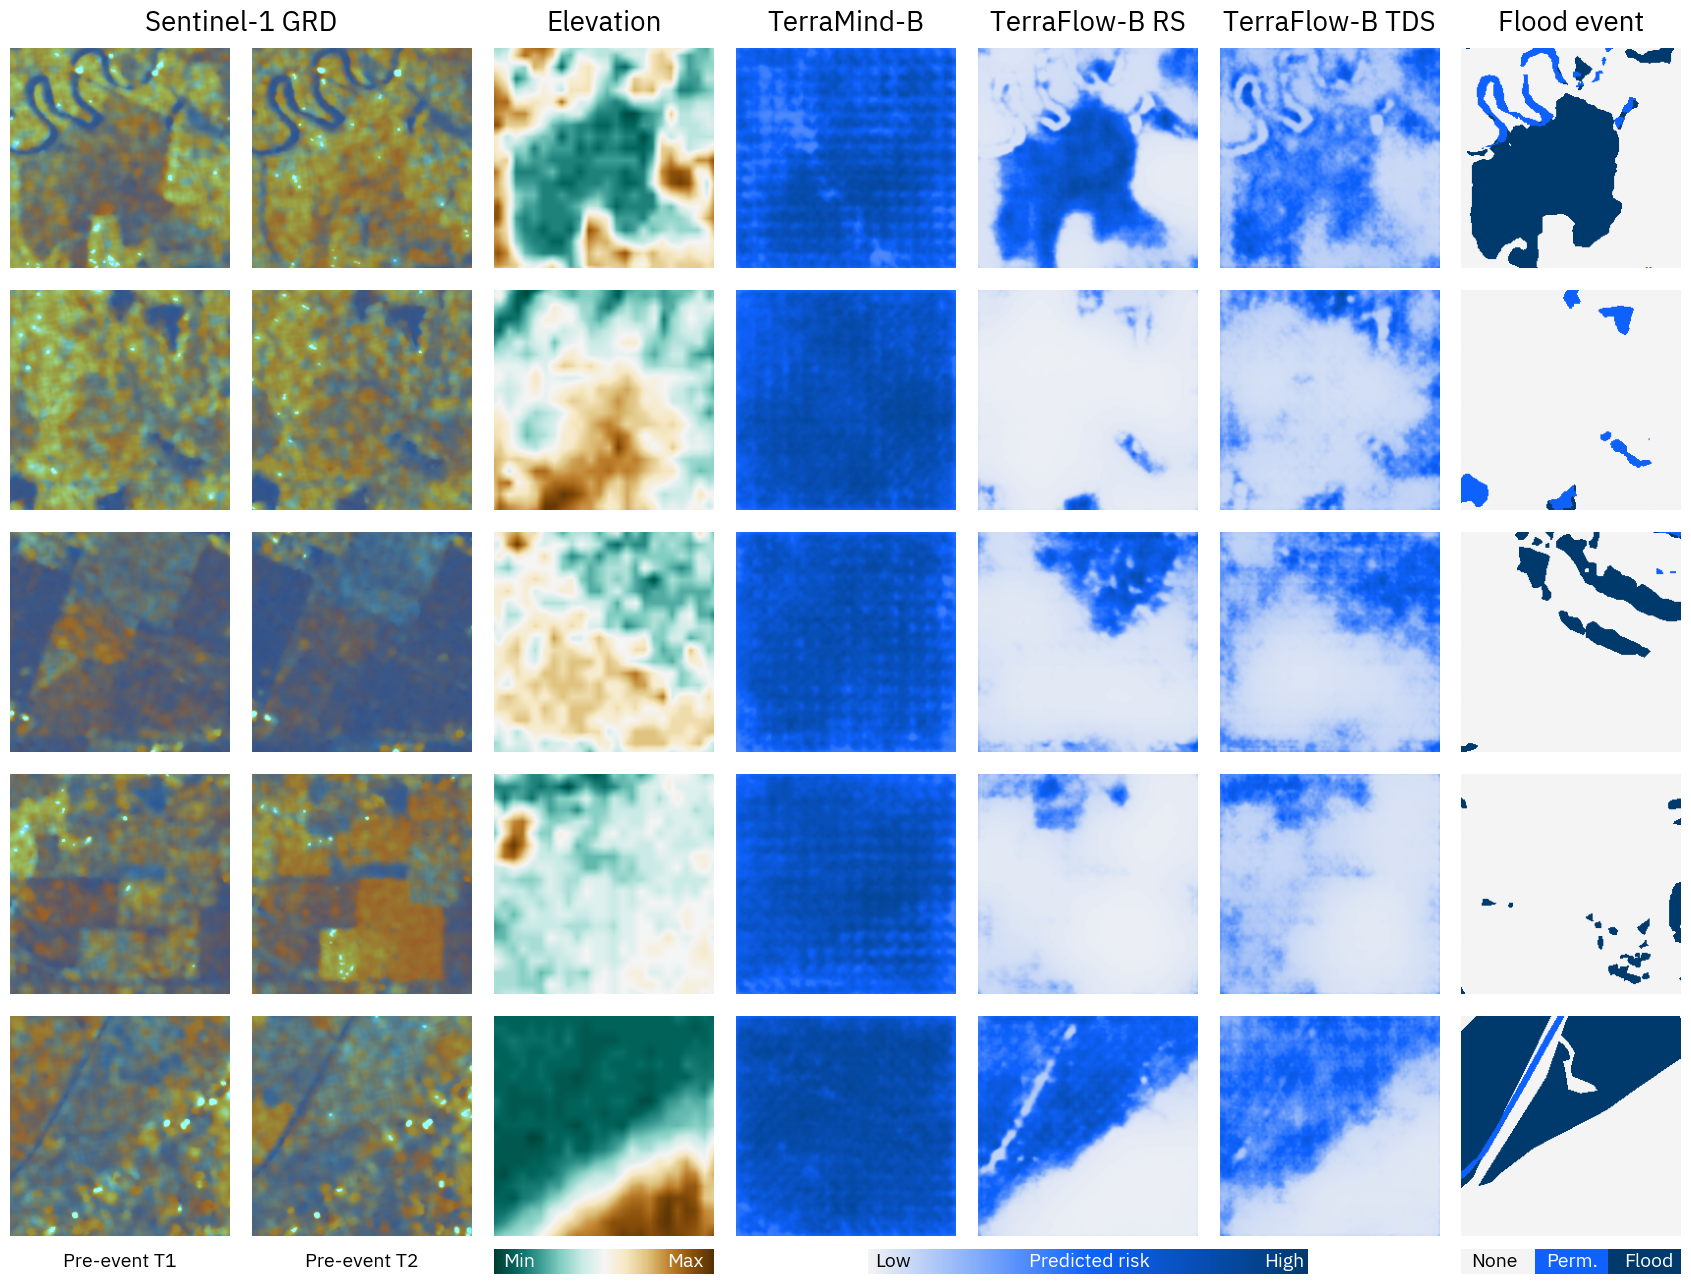

In [41]:
# ================================================================
# Select rows to visualize
# ================================================================
idxs = [4,7,3,1,9] # 1, 9,
B = len(idxs)

fig, axs = plt.subplots(
    B, 7,
    figsize=(17.5, B * 2.5),
    squeeze=False
)
fig.tight_layout(pad=0)
fig.subplots_adjust(wspace=0.1, hspace=0.1)
legend_height = 0.1 / B

# ------------------------------------------------------------
# Column titles (LaTeX only for T_*)
# ------------------------------------------------------------
col_titles = [
    r"Elevation",
    r"TerraMind-B",
    r"TerraFlow-B RS",
    r"TerraFlow-B TDS",
    r"Flood event",
]

for c, title in enumerate(col_titles):
    axs[0, c+2].set_title(title, fontsize=20, pad=12)

x0 = axs[0, 0].get_position().x0
x1 = axs[0, 1].get_position().x1
width = axs[0, 0].get_position().width / 2
y0 = axs[B-1, 0].get_position().y0 - legend_height
center_x = (x0 + x1) / 2

fig.text(center_x, 0.997, 'Sentinel-1 GRD',
         ha='center', va='bottom', fontsize=20)
fig.text(x0 + width, y0, 'Pre-event T1',
         ha='center', va='center', fontsize=14)
fig.text(x1 - width, y0, 'Pre-event T2',
         ha='center', va='center', fontsize=14)

# --- Colorbar ---
c = COLORS['blue']
cmap = LinearSegmentedColormap.from_list("tmp", [to_rgb(c["neg"]), to_rgb(c["mid"]), to_rgb(c["pos"])], N=256)

pos = axs[-1, 2].get_position()
cbar_ax = fig.add_axes([pos.x0, pos.y0 - 1.5 * legend_height, pos.width, legend_height])
cbar = fig.colorbar(axs[-1, 2].imshow(np.random.rand(10, 10), cmap='BrBG_r'), cax=cbar_ax, orientation="horizontal")
cbar.ax.set_xticks([])
cbar.ax.text(0.05, 0.5, "Min", ha="left", va="center", fontsize=14, color="white")
cbar.ax.text(0.95, 0.5, "Max", ha="right", va="center", fontsize=14, color="white")
cbar.outline.set_visible(False)

pos = axs[-1, 4].get_position()
cbar_ax = fig.add_axes([pos.x0 - pos.width/2, pos.y0 - 1.5 * legend_height, pos.width * 2, legend_height])
cbar = fig.colorbar(axs[-1, 4].imshow(np.random.rand(10, 10), cmap=cmap), cax=cbar_ax, orientation="horizontal")
cbar.ax.set_xticks([])
cbar.ax.text(0.02, 0.5, "Low", ha="left", va="center", fontsize=14, color="black")
cbar.ax.text(0.5, 0.5, "Predicted risk", ha="center", va="center", fontsize=14, color="white")
cbar.ax.text(0.98, 0.5, "High", ha="right", va="center", fontsize=14, color="white")
cbar.outline.set_visible(False)

gt_cmap = LinearSegmentedColormap.from_list('gt', [to_rgb(c["neg"]), to_rgb(c["mid"]), to_rgb(c["pos"])], N=3)
pos = axs[-1, 6].get_position()
cbar_ax = fig.add_axes([pos.x0, pos.y0 - 1.5 * legend_height, pos.width, legend_height])
cbar = fig.colorbar(axs[-1, 6].imshow(np.random.rand(10, 10), cmap=gt_cmap), cax=cbar_ax, orientation="horizontal")
cbar.ax.set_xticks([])
cbar.ax.text(0.05, 0.5, "None", ha="left", va="center", fontsize=14, color="black")
cbar.ax.text(0.5, 0.5, "Perm.", ha="center", va="center", fontsize=14, color="white")
cbar.ax.text(0.95, 0.5, "Flood", ha="right", va="center", fontsize=14, color="white")
cbar.outline.set_visible(False)


for i, b in enumerate(idxs):
    # ------------------------------------------------------------
    # Inputs (two times)
    # ------------------------------------------------------------

    s1_t0 = inputs["SEN1GRD"][b, :, 0]
    s1_t1 = inputs["SEN1GRD"][b, :, 1]

    dem = inputs["DEM"][b]

    s1_rgb_t0 = s1_to_rgb(s1_t0)
    s1_rgb_t1 = s1_to_rgb(s1_t1)

    dem_rgb   = dem_to_rgb(dem)

    # ------------------------------------------------------------
    # Prediction & target
    # ------------------------------------------------------------
    pred_tm = torch.clamp(tm_outputs[b], 0.0, 1.0).clone().numpy()
    pred_tm = process_pred(pred_tm, thr=0.7)
    pred_tf_rs = torch.clamp(tf_rs_outputs[b], 0.0, 1.0).clone().numpy()
    pred_tf_rs = process_pred(pred_tf_rs, thr=0.3)
    pred_tf_tds = torch.clamp(tf_tds_outputs[b], 0.0, 1.0).clone().numpy()
    pred_tf_tds = process_pred(pred_tf_tds, thr=0.3)
    tgt  = torch.clamp(targets[b],  0.0, 2.0).clone().numpy() / 2

    # ------------------------------------------------------------
    # Plot row
    # ------------------------------------------------------------
    axs[i, 0].imshow(s1_rgb_t0)
    axs[i, 1].imshow(s1_rgb_t1)
    axs[i, 2].imshow(dem_rgb)
    axs[i, 3].imshow(cmap(pred_tm))
    axs[i, 4].imshow(cmap(pred_tf_rs))
    axs[i, 5].imshow(cmap(pred_tf_tds))
    axs[i, 6].imshow(cmap(tgt))

    for c in range(7):
        axs[i, c].axis("off")

    # Label with original index
    axs[i, 0].set_ylabel(f"Idx {b}", rotation=0, labelpad=40, fontsize=10)

plt.savefig(
    f"{ROOT_DIR}/generated_images/figure_kurosiwofloods_comparisons.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches = 0
)
plt.show()
